In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

In [3]:
dataset_A = np.random.normal(loc=50, scale=10, size=500)

dataset_B = np.random.exponential(scale=1, size=500)
dataset_B = (dataset_B - dataset_B.min()) / (dataset_B.max() - dataset_B.min()) * 100

In [4]:

data1 = np.random.normal(loc=30, scale=5, size=250)
data2 = np.random.normal(loc=70, scale=5, size=250)

dataset_C = np.concatenate([data1, data2])

In [5]:
def summarize(data):

    mean = np.mean(data)
    median = np.median(data)
    mode = stats.mode(data, keepdims=True)[0][0]

    std = np.std(data)
    variance = np.var(data)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)

    return [mean, median, mode, std, variance, iqr, skewness, kurtosis]

In [6]:

summary = pd.DataFrame({
    "Dataset A (Symmetric)": summarize(dataset_A),
    "Dataset B (Right-skewed)": summarize(dataset_B),
    "Dataset C (Bimodal)": summarize(dataset_C)
},
index=[
    "Mean",
    "Median",
    "Mode",
    "Std Dev",
    "Variance",
    "IQR",
    "Skewness",
    "Kurtosis"
])

summary = summary.round(2)

summary

,Dataset A (Symmetric),Dataset B (Right-skewed),Dataset C (Bimodal)
Mean,50.07,16.17,50.33
Median,50.13,11.29,49.53
Mode,17.59,0.00,15.52
Std Dev,9.80,15.97,20.28
Variance,96.09,255.13,411.19
IQR,13.37,18.65,39.01
Skewness,0.18,1.77,0.01
Kurtosis,0.26,3.98,-1.76



### Similar Mean - of Dataset A and Dataset C may be similar (50.07 and 50.33) Standard deviation and variance - they can also appear similar between datasets depending on spread.

### Different Skewness clearly identifies Dataset B as right-skewed. Median vs Mean difference in Dataset B indicates skew. IQR is larger for Dataset C because the data is split between two groups. Kurtosis also differs, reflecting tail behavior.

In [7]:

datasets = [dataset_A, dataset_B, dataset_C]
names = ["Dataset A (Symmetric)", "Dataset B (Right-Skewed)", "Dataset C (Bimodal)"]

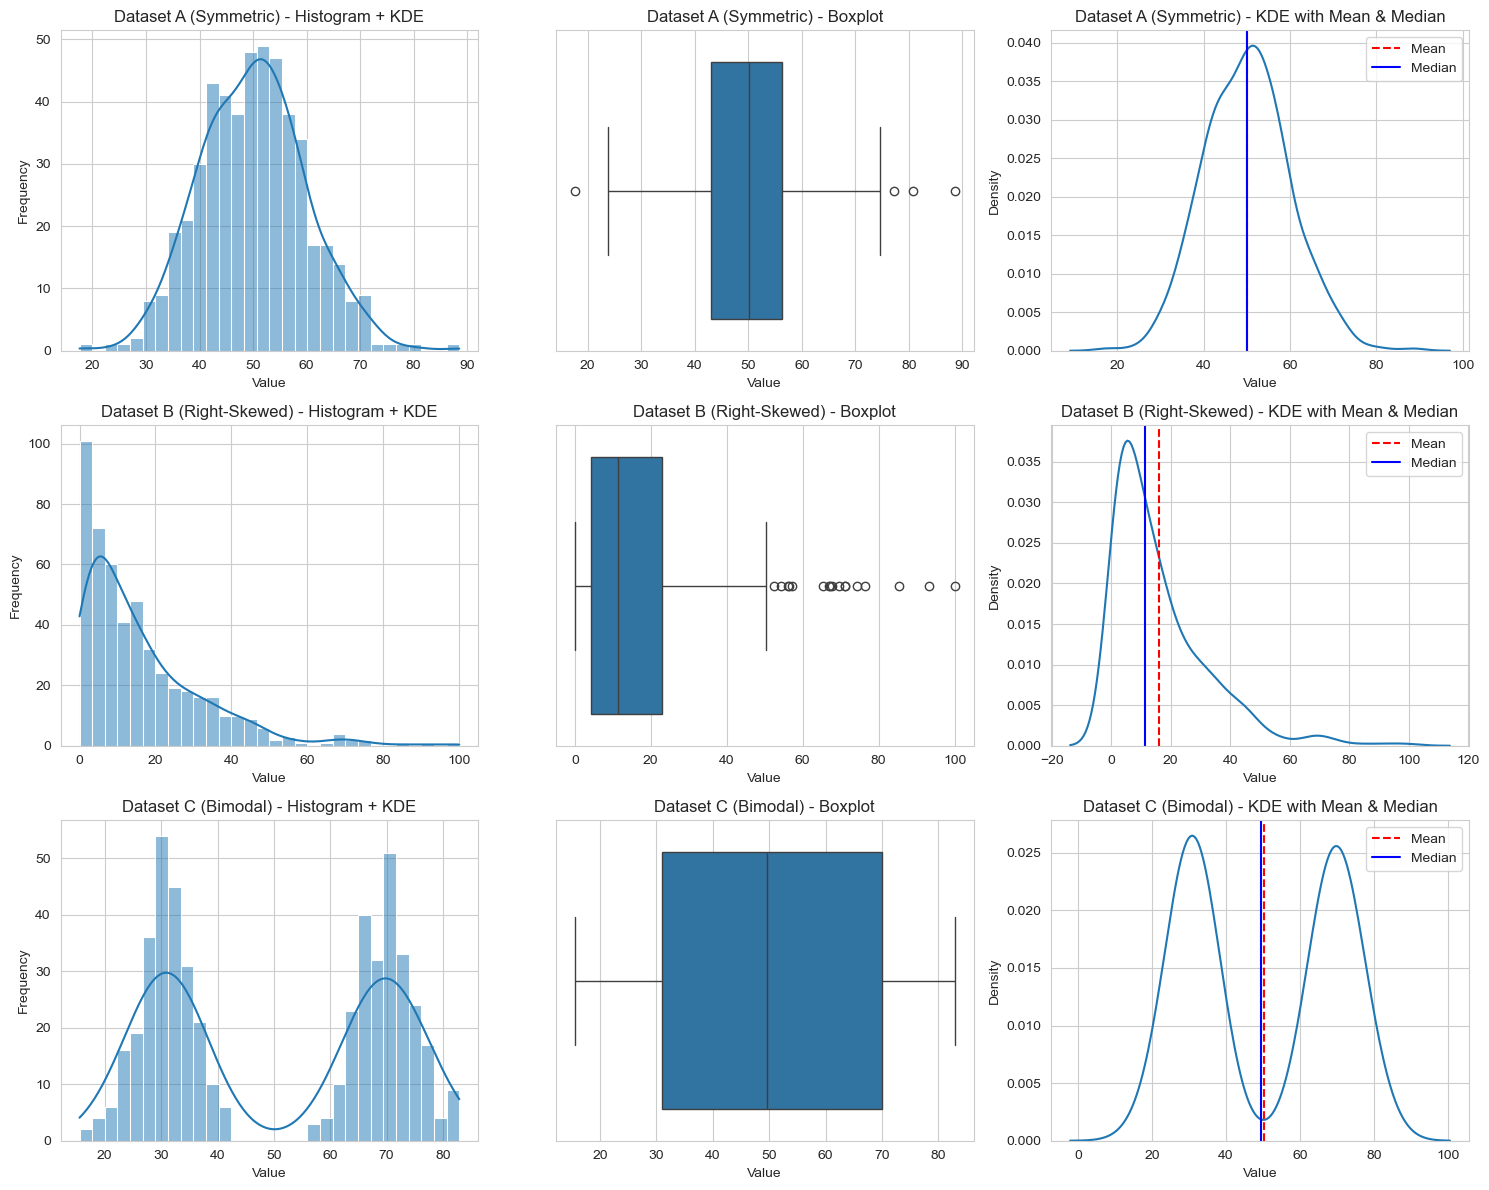

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, data in enumerate(datasets):

    mean = np.mean(data)
    median = np.median(data)

    # Histogram + KDE
    sns.histplot(data, bins=30, kde=True, ax=axes[i,0])
    axes[i,0].set_title(f"{names[i]} - Histogram + KDE")
    axes[i,0].set_xlabel("Value")
    axes[i,0].set_ylabel("Frequency")

    # Boxplot (horizontal)
    sns.boxplot(x=data, ax=axes[i,1])
    axes[i,1].set_title(f"{names[i]} - Boxplot")
    axes[i,1].set_xlabel("Value")

    # KDE with mean/median
    sns.kdeplot(data, ax=axes[i,2])
    axes[i,2].axvline(mean, color='red', linestyle='--', label='Mean')
    axes[i,2].axvline(median, color='blue', linestyle='-', label='Median')
    axes[i,2].set_title(f"{names[i]} - KDE with Mean & Median")
    axes[i,2].set_xlabel("Value")
    axes[i,2].set_ylabel("Density")
    axes[i,2].legend()

plt.tight_layout()
plt.show()

In [9]:

dataset_modified = dataset_A.copy()

# Find indices of the 5 largest values
largest_idx = np.argsort(dataset_modified)[-5:]

# Multiply them by 10
dataset_modified[largest_idx] = dataset_modified[largest_idx] * 10

In [10]:

def summarize(data):

    mean = np.mean(data)
    median = np.median(data)
    mode = stats.mode(data, keepdims=True)[0][0]

    std = np.std(data)
    variance = np.var(data)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)

    return [mean, median, mode, std, variance, iqr, skewness, kurtosis]

In [11]:

summary = pd.DataFrame({
    "Original Dataset A": summarize(dataset_A),
    "Modified Dataset (Outliers)": summarize(dataset_modified)
},
index=[
    "Mean",
    "Median",
    "Mode",
    "Std Dev",
    "Variance",
    "IQR",
    "Skewness",
    "Kurtosis"
])

summary = summary.round(2)

summary

,Original Dataset A,Modified Dataset (Outliers)
Mean,50.07,57.17
Median,50.13,50.13
Mode,17.59,17.59
Std Dev,9.80,74.31
Variance,96.09,5521.42
IQR,13.37,13.37
Skewness,0.18,9.70
Kurtosis,0.26,94.18


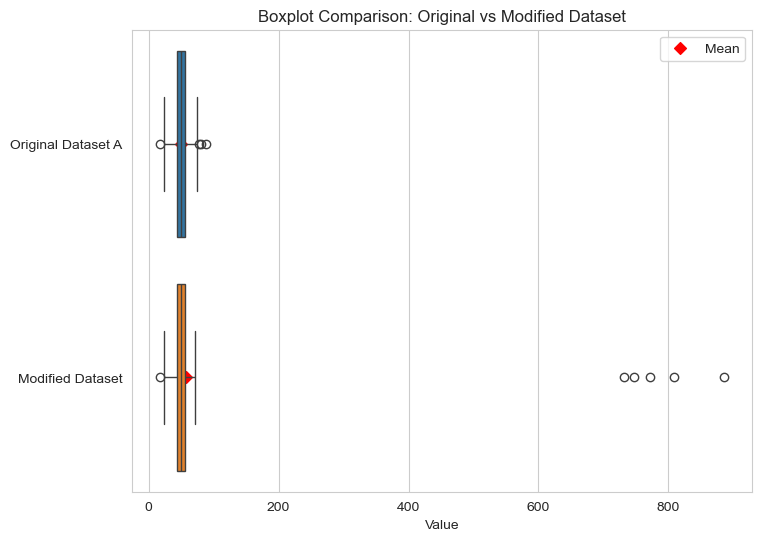

In [12]:
plt.figure(figsize=(8,6))

sns.boxplot(data=[dataset_A, dataset_modified], orient="h")

# overlay means as diamonds
plt.scatter(np.mean(dataset_A), 0, marker='D', color='red', label='Mean')
plt.scatter(np.mean(dataset_modified), 1, marker='D', color='red')

plt.yticks([0,1], ["Original Dataset A", "Modified Dataset"])
plt.xlabel("Value")
plt.title("Boxplot Comparison: Original vs Modified Dataset")
plt.legend()

plt.show()


### Which statistics changed the most? Which were robust?

The statistics that changed the most were mean, standard deviation, variance, skewness, and kurtosis. This happened because extreme outliers strongly influence statistics that depend on the magnitude of values.

The statistics that remained relatively robust were median and IQR. These measures are based on the order of the data rather than the exact values, so a few extreme observations do not significantly affect them.

### If reporting a "typical" value, would you choose the mean or the median?

For the modified dataset, the median would be the better measure of a typical value.

The extreme outliers pull the mean upward, making it no longer representative of the majority of the data. The median, however, remains close to the center of the dataset and is therefore a more reliable measure of the typical observation.